In [203]:
# Fuente de los datos:
# https://resultados2023.comunidad.madrid/es/

import pandas as pd
import matplotlib.pyplot as plt


URL = 'http://fpaniaguapython.github.io/datos/DatEscrut_Def_Auto_2023_Madrid_Municipios.csv'

try:
    # El archivo utiliza comas (,) como separador en lugar de punto y coma (;)
    df = pd.read_csv(URL, encoding='latin-1', sep=',', thousands='.', decimal=',')
    print("Cargado con éxito usando encoding 'latin-1' y separador de coma")
    display(df.head())
except Exception as e:
    print(f"Error al cargar: {e}")

Cargado con éxito usando encoding 'latin-1' y separador de coma


,Codcir,Codmun,Municipio,Unnamed: 3,Censo,Certif. Alta,Censo Total,Votos Totales,Votos Blancos,Votos Nulos,...,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
0,28,1.0,La Acebeda,NaN,64,0,64,54,0,1,...,0,0,0,6,0,0,0,1,6,0
1,28,2.0,Ajalvir,NaN,3359,0,3359,2287,33,28,...,1,0,2,395,27,17,8,260,46,2
2,28,3.0,Alameda del Valle,NaN,194,0,194,168,1,3,...,0,0,0,27,3,2,1,18,7,1
3,28,4.0,El Álamo,NaN,7072,6,7078,4732,36,58,...,2,1,6,531,23,25,2,492,164,6
4,28,5.0,Alcalá de Henares,NaN,138572,1,138573,94847,1032,981,...,26,88,115,14951,1553,761,86,7659,4082,120


In [204]:
df.tail()

,Codcir,Codmun,Municipio,Unnamed: 3,Censo,Certif. Alta,Censo Total,Votos Totales,Votos Blancos,Votos Nulos,...,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
176,28,901.0,Lozoyuela-Navas-Sieteiglesias,NaN,994,0,994,702,3,11,...,1,1,2,103,5,6,4,43,62,3
177,28,902.0,Puentes Viejas,NaN,565,0,565,442,4,5,...,0,0,1,92,4,3,0,42,34,4
178,28,903.0,Tres Cantos,NaN,37959,4,37963,29203,486,225,...,5,14,27,5501,792,164,16,1730,1308,38
179,28,990.0,Residentes ausentes-Madrid,NaN,372447,0,372447,28860,179,2109,...,26,53,94,4385,528,289,47,2453,2073,168
180,Total,NaN,NaN,NaN,5211765,179,5211944,3413819,35107,34342,...,2544,2404,4148,620631,52925,23451,2779,248379,161032,5376


In [205]:
# Eliminación de la última fila
df = df.iloc[:-1]
df.tail()

,Codcir,Codmun,Municipio,Unnamed: 3,Censo,Certif. Alta,Censo Total,Votos Totales,Votos Blancos,Votos Nulos,...,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
175,28,183.0,Zarzalejo,NaN,1260,0,1260,901,12,18,...,0,1,2,213,4,5,1,53,92,1
176,28,901.0,Lozoyuela-Navas-Sieteiglesias,NaN,994,0,994,702,3,11,...,1,1,2,103,5,6,4,43,62,3
177,28,902.0,Puentes Viejas,NaN,565,0,565,442,4,5,...,0,0,1,92,4,3,0,42,34,4
178,28,903.0,Tres Cantos,NaN,37959,4,37963,29203,486,225,...,5,14,27,5501,792,164,16,1730,1308,38
179,28,990.0,Residentes ausentes-Madrid,NaN,372447,0,372447,28860,179,2109,...,26,53,94,4385,528,289,47,2453,2073,168


In [206]:
# Eliminación de la columna "Unnamed: 3"
# df_sin_columna = df.drop(columns=["Unnamed: 3"])
df.drop(columns=["Unnamed: 3"], inplace=True)
df.head()

,Codcir,Codmun,Municipio,Censo,Certif. Alta,Censo Total,Votos Totales,Votos Blancos,Votos Nulos,Abstención,...,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
0,28,1.0,La Acebeda,64,0,64,54,0,1,10,...,0,0,0,6,0,0,0,1,6,0
1,28,2.0,Ajalvir,3359,0,3359,2287,33,28,1072,...,1,0,2,395,27,17,8,260,46,2
2,28,3.0,Alameda del Valle,194,0,194,168,1,3,26,...,0,0,0,27,3,2,1,18,7,1
3,28,4.0,El Álamo,7072,6,7078,4732,36,58,2346,...,2,1,6,531,23,25,2,492,164,6
4,28,5.0,Alcalá de Henares,138572,1,138573,94847,1032,981,43726,...,26,88,115,14951,1553,761,86,7659,4082,120


In [207]:
# El 1 indica que se concatenan las columnas
votos = pd.concat([df.iloc[:,2],df.iloc[:,12:]], axis=1)
votos

,Municipio,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
0,La Acebeda,31,0,9,0,0,0,6,0,0,0,1,6,0
1,Ajalvir,1187,1,280,1,0,2,395,27,17,8,260,46,2
2,Alameda del Valle,74,0,31,0,0,0,27,3,2,1,18,7,1
3,El Álamo,2345,7,1034,2,1,6,531,23,25,2,492,164,6
4,Alcalá de Henares,41335,150,21908,26,88,115,14951,1553,761,86,7659,4082,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Zarzalejo,350,1,148,0,1,2,213,4,5,1,53,92,1
176,Lozoyuela-Navas-Sieteiglesias,323,1,134,1,1,2,103,5,6,4,43,62,3
177,Puentes Viejas,202,1,50,0,0,1,92,4,3,0,42,34,4
178,Tres Cantos,14204,70,4623,5,14,27,5501,792,164,16,1730,1308,38


In [208]:
# Asignar la columna de municipios a los índices de las filas
votos.set_index(votos['Municipio'].str.upper(), inplace=True)
votos.drop(columns=['Municipio'], inplace=True)
votos

,PP,PUM+J,PSOE,ULEG,PH,PCTE,MM-VQ,CS,PACMA,FE DE LAS JONS,VOX,PODEMOS-IU-AV,PFE
Municipio,,,,,,,,,,,,,
LA ACEBEDA,31,0,9,0,0,0,6,0,0,0,1,6,0
AJALVIR,1187,1,280,1,0,2,395,27,17,8,260,46,2
ALAMEDA DEL VALLE,74,0,31,0,0,0,27,3,2,1,18,7,1
EL ÁLAMO,2345,7,1034,2,1,6,531,23,25,2,492,164,6
ALCALÁ DE HENARES,41335,150,21908,26,88,115,14951,1553,761,86,7659,4082,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZARZALEJO,350,1,148,0,1,2,213,4,5,1,53,92,1
LOZOYUELA-NAVAS-SIETEIGLESIAS,323,1,134,1,1,2,103,5,6,4,43,62,3
PUENTES VIEJAS,202,1,50,0,0,1,92,4,3,0,42,34,4


Introduce el nombre de un municipio: Móstoles


Text(0.5, 1.0, 'Votos en el Municipio de MÓSTOLES')

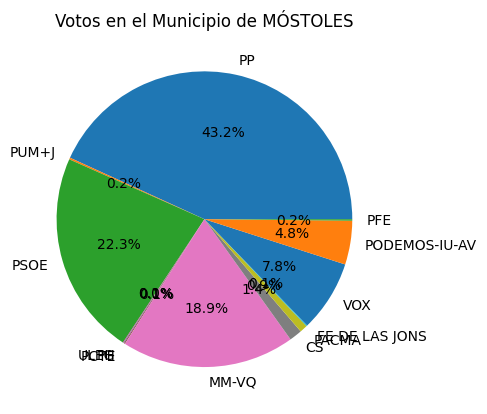

In [209]:
municipio = input('Introduce el nombre de un municipio: ')
municipio = municipio.upper()
votos_alcorcon = votos.loc[municipio]
plt.pie(votos_alcorcon, labels=votos_alcorcon.index, autopct='%1.1f%%')
plt.title(f'Votos en el Municipio de {municipio}')
